In [973]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import nnls
import matplotlib.pyplot as plt
import trecs
from trecs.random import Generator
from trecs.matrix_ops import inner_product
from trecs.models import ContentFiltering, PopularityRecommender, ImplicitMF, SocialFiltering
from trecs.components import Users, Items, Creators, ActualUserScores
from trecs.metrics import Measurement, InteractionMeasurement, InteractionSpread, MSEMeasurement, InteractionSimilarity
from chaney_utils import (
    mu_sigma_to_alpha_beta,
    gen_social_network,
    MeanInteractionDistance,
    SimilarUserInteractionSimilarity,
    transform_relative_to_ideal,
    MeanDistanceSimUsers,
)
from collections import defaultdict
import copy

# Clases
Clases para Creación de Items, Usuarios de Chaney, y MSE con valores nulos para items que no han aparecido.

In [974]:
class NewItemFactory(Creators):
    def __init__(self, items, items_per_iteration):
        self.items = items
        self.items_per_iteration = items_per_iteration
        self.idx = 0
    def generate_items(self):
        if self.idx > self.items.shape[1]:
            return np.empty((self.items.shape[0], 0))
            #raise RuntimeError("Ran out of items to generate!")
        idx_start = self.idx
        idx_end = self.idx + self.items_per_iteration
        self.idx = idx_end
        return self.items[:, idx_start:idx_end]

In [975]:
class ChaneyUsers(Users):
    def __init__(self, known_scores, *args, **kwargs):
        self.known_scores = np.copy(known_scores)
        super().__init__(*args, **kwargs)
    
    def compute_user_scores(self, items):
        self.actual_user_scores = ActualUserScores(self.known_scores)
    
    def score_new_items(self, items):
        pass

    def get_user_feedback(self, *args, **kwargs):
        interactions = super().get_user_feedback(*args, **kwargs)
        return interactions

In [976]:
class MultiTraitUsers(ChaneyUsers):
    def __init__(self, num_users, true_scores, social_network, traits, *args, **kwargs):
        self.trait_distribution = np.tile(traits, (num_users, 1))
        self.trait_distribution[:, 0] += 1 - self.trait_distribution.sum(axis=1)
        self.total_item_interactions = np.array([], dtype=int)
        self.social_network = social_network
        self.shared_items = np.empty(num_users, dtype=object)
        self.shared_items[...] = [[] for _ in range(self.shared_items.shape[0])]
        self.scores_after_interaction = true_scores
        super().__init__(*args, **kwargs)
    
    def score_new_items(self, items):
        new_items_interactions = np.zeros(items.shape[1], dtype=int)
        self.total_item_interactions = np.hstack((self.total_item_interactions, new_items_interactions))
    
    def get_user_feedback(self, items_shown):
        trait_distribution_no_items_shared = self.trait_distribution.copy()
        b = 1/(trait_distribution_no_items_shared[:, 0] + trait_distribution_no_items_shared[:, 1])
        trait_distribution_no_items_shared[:, [0, 1]] *= b[:, np.newaxis]
        trait_distribution_no_items_shared[:, 2] = 0.0
        trait_distribution_no_items_shared[:, 0] += 1 - trait_distribution_no_items_shared.sum(axis=1)

        cond = np.array([x != [] for x in self.shared_items])
        trait_distribution_no_items_shared[cond] = self.trait_distribution[cond]

        users_selections = np.array([self.rng.choice(np.arange(trait_distribution_no_items_shared.shape[1]), size=1, p=row) for row in trait_distribution_no_items_shared])
        users_selections = users_selections.flatten()

        if not self.repeat_interactions:
            prev_interacted_scores = self.actual_user_scores.get_item_scores(self.user_interactions)
            self.actual_user_scores.set_item_scores_to_value(self.user_interactions, float("-inf"))
        
        popular_items_tiebreak = np.zeros(
            self.total_item_interactions.shape, dtype=[("rank", "u4"), ("random", "f8")]
        )
        popular_items_tiebreak["rank"] = self.total_item_interactions
        popular_items_tiebreak["random"] = self.rng.random(self.total_item_interactions.shape)
        popular_items_rank = np.argsort(popular_items_tiebreak, order=["rank", "random"])[::-1]

        interactions = []
        for i in range(users_selections.shape[0]):
            if users_selections[i] == 0:
                item_list = items_shown[i]
            elif users_selections[i] == 1:
                item_list = popular_items_rank
            elif users_selections[i] == 2:
                item_list = np.array(self.shared_items[i])
            user_item_scores_list = self.actual_user_scores.value[np.repeat(i, item_list.shape[0]), item_list]
            user_item_scores_list = self.attention_transform(user_item_scores_list)
            chosen_item = item_list[np.argmax(user_item_scores_list)]
            interactions += [chosen_item]
            if users_selections[i] == 2:
                self.shared_items[i] = list(filter(lambda x: x != chosen_item, self.shared_items[i]))
        interactions = np.array(interactions, dtype=int)
        
        new_item_interactions = np.bincount(interactions)
        self.total_item_interactions[:len(new_item_interactions)] += new_item_interactions

        if not self.repeat_interactions:
            self.actual_user_scores.set_item_scores_to_value(
                self.user_interactions, prev_interacted_scores
            )
            interactions_col = interactions.reshape((-1, 1))
            self.user_interactions = np.hstack([self.user_interactions, interactions_col])
        
        true_scores_from_interactions = self.scores_after_interaction[np.arange(self.scores_after_interaction.shape[0]), interactions]
        threshold = 0.3 # ??? debe haber mejor forma de hacer esto
        for i in range(true_scores_from_interactions.shape[0]):
            if true_scores_from_interactions[i] > threshold:
                connected_indices = np.where(self.social_network[i] == 1)[0]
                for index in connected_indices:
                    if not self.repeat_interactions:
                        if interactions[i] not in self.user_interactions[index]:
                            self.shared_items[index].append(interactions[i])
                    else:
                        self.shared_items[index].append(interactions[i])
        
        # print("shared items:", self.shared_items)
        return interactions
    
    def attention_transform(self, recommended_item_scores):
        if len(recommended_item_scores.shape) > 1:
            return super().attention_transform(recommended_item_scores)
        if self.attention_exp != 0:
            num_items = recommended_item_scores.shape[0]
            idxs = np.arange(num_items) + 1
            multiplier = np.power(idxs, self.attention_exp)
            return recommended_item_scores * multiplier
        else:
            return recommended_item_scores

In [977]:
class RMSEMeasurementFixed(MSEMeasurement):
    def measure(self, recommender):
        predicted_scores_by_RS = recommender.score_fn(recommender.predicted_user_profiles, recommender.predicted_item_attributes)
        actual_user_scores_resized = recommender.users.actual_user_scores.value[:, :predicted_scores_by_RS.shape[1]]
        diff = predicted_scores_by_RS - actual_user_scores_resized
        if diff.size == 0:
            self.observe(None)
        else:
            result_data = (diff ** 2).mean()
            if result_data != float('-inf'):
                self.observe(result_data ** (0.5), copy=False)
            else:
                self.observe(0.0)

In [978]:
class ChaneyContent(ContentFiltering):
    """
    Chaney ContentFiltering model which uses NNLS solver
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _update_internal_state(self, interactions):
        # update cumulative interactions
        num_new_items = self.items_hat.shape[1] - self.cumulative_interactions.shape[1] # how many new items were added to the system?
        if num_new_items > 0:
            self.cumulative_interactions = np.hstack([self.cumulative_interactions, np.zeros((self.num_users, num_new_items))]) # add new items to cumulative interactions
        self.cumulative_interactions[self.users.user_vector, interactions] += 1

    def train(self):
        if hasattr(self, 'cumulative_interactions') and self.cumulative_interactions.sum() > 0: # if there are interactions present:
            items_to_train = self.cumulative_interactions.shape[1] # can't train representations for new items before interactions have happened!
            for i in range(self.num_users):
                item_attr = self.items_hat.value[:, :items_to_train].T
                self.users_hat.value[i, :] = nnls(item_attr, self.cumulative_interactions[i, :])[0] # solve for Content Filtering representation using nnls solver
            num_new_items = self.items_hat.shape[1] - self.cumulative_interactions.shape[1] # how many new items were added to the system?

        else:
            self.cumulative_interactions = np.zeros((self.users_hat.shape[0], self.items_hat.shape[1]))
        super().train()


In [979]:
class IdealRecommender(ContentFiltering):
    """
    With the Ideal Recommender, we make the *strong assumption* that the true scores are provided
    to the recommender system through a custom scoring function, which always returns the true
    underlying user-item scores. Therefore, this class is pretty much an empty skeleton; the only
    modification is that we don't update any internal state of the recommender at each time step.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _update_internal_state(self, interactions):
        # do not change users_hat!
        pass


In [980]:
class RandomRecommender(ContentFiltering):
    """
    Random recommender - randomly update user representation at every step
    """
    def _update_internal_state(self, interactions):
        self.items_hat.value[:, :] = self.random_state.random(self.items_hat.shape)
        self.users_hat.value[:, :] = self.random_state.random(self.users_hat.shape)

    def process_new_items(self, new_items):
        """
        Generate random attributes for new items.
        """
        num_items = new_items.shape[1]
        num_attr = self.items_hat.value.shape[0]
        item_representation = self.random_state.random((num_attr, num_items))
        return item_representation

In [981]:
class InteractionTracker(Measurement):
    """ Tracks all user interactions up to the current timepoint. In the context of replication,
        it will be used to track the items that users interact with in the ideal
        recommender. We need this in order to calculate homogenization of other non-ideal
        RS algorithms, relative to the ideal recommender.
    """
    def __init__(self, name="interaction_history", verbose=False):
        Measurement.__init__(self, name, verbose)

    def measure(self, recommender):
        interactions = recommender.interactions
        if recommender.interactions.size == 0:
            # at beginning of simulation, there are no interactions
            self.observe(None)
            return
        self.observe(np.copy(interactions).reshape((-1, 1)))

# Funciones necesarias

In [982]:
def interleave_new_items(generator):
    def interleaving_fn(k, item_indices):
        num_users = item_indices.shape[0]
        indices = item_indices[:, -k:]
        values = generator.random(indices.shape)
        order = values.argsort(axis=1) # randomly sort indices within rows
        rows = np.tile(np.arange(num_users).reshape((-1, 1)), indices.shape[1])
        return indices[rows, order]
    return interleaving_fn

In [983]:
def perfect_scores(num_items_per_iter, true_scores):
    """ This custom scoring function ensures that all items in the system
        that are created after a certain point are given a score of negative
        infinity, ensuring that they will be at the very bottom of any recommendation
        list. Otherwise, we return the "true scores" specified in the
        true_scores array. Additionally, it ensures that the true utilities are
        returned for each item. This is the scoring used by the IdealRecommender.
    """
    score_copy = np.copy(true_scores)
    def score_fn(users, items):
        predicted_scores = np.copy(score_copy)
        num_users, num_items = users.shape[0], items.shape[1]
        # all predicted scores for these "new" items will be negative infinity,
        # ensuring they never get recommended; instead, they are interleaved into the recommendation
        # set
        predicted_scores = predicted_scores[:num_users, :num_items] # subset to correct dimensions
        if items.shape[1] == num_items_per_iter: # EDGE CASE: when num_items_per_iter = num_items
            # all predicted scores for these "new" items will be negative infinity,
            # ensuring they never get recommended
            predicted_scores[:, :] = float('-inf')
        return predicted_scores
    return score_fn

In [984]:
def exclude_new_items(num_items_per_iter):
    """ This custom scoring function ensures that all items in the system
        that are created after a certain point are given a score of negative
        infinity, ensuring that they will be at the very bottom of any recommendation
        list. This ensures that only the items in the training phase get recommended;
        new items are only recommended via the interleaving procedure.
    """
    # score_fn is called by process_new_items and by train.
    # therefore, when score_fn is being called the first time, we will give all new items
    # scores of negative infinity; then, when train() is called, the actual
    # scores will be supplied.
    def score_fn(users, items):
        predicted_scores = inner_product(users, items)
        if items.shape[1] == num_items_per_iter: # EDGE CASE: when num_items_per_iter = num_items
            # all predicted scores for these "new" items will be negative infinity,
            # ensuring they never get recommended
            predicted_scores[:, :] = float('-inf')
        return predicted_scores
    return score_fn

In [985]:
def graph_metrics_and_models(train_results, metric_keys, model_keys, mean_sigma=0, mult_sd=0, conf_sigma=0, relative_to_ideal=False):
    num_subplots = len(metric_keys)
    plt.figure(figsize=(10, 6 * num_subplots))
    for i in range(len(metric_keys)):
        me = metric_keys[i]
        plt.subplot(len(metric_keys), 1, i+1)
        plt.title(me)
        if me == "mse":
            plt.yscale('log')
        
        results = train_results
        metric_independent_from_ideal = not (me == "similar_user_jaccard" or me == "sim_user_dist")
        if relative_to_ideal:
            results = transform_relative_to_ideal(results, me, model_keys, metric_independent_from_ideal)
        else:
            if not metric_independent_from_ideal:
                first_model_key = list(train_results[me].keys())[0]
                sims = len(results[me][first_model_key])
                iters = len(results[me][first_model_key][0])
                results[me]["ideal"] = np.zeros((sims, iters))
        
        for j in range(len(model_keys)):
            mo = model_keys[j]
            if not isinstance(results[me][mo], np.ndarray):
                results[me][mo] = np.array(results[me][mo])
            if mean_sigma > 0:
                values = gaussian_filter1d(results[me][mo].mean(axis=0), sigma=mean_sigma)
            else:
                values = results[me][mo].mean(axis=0)
            print("Metric", me, "model", mo, "values:", values)
            if me == "mse":
                line = plt.plot(values, label=mo)
            else:
                line = plt.plot(values, label=mo)
            line_color = line[0].get_color()
            plt.grid()
            if mult_sd > 0:
                std = results[me][mo].std(axis=0)
                timesteps = np.arange(len(std))
                low = values - mult_sd * std
                high = values + mult_sd * std
                if conf_sigma > 0:
                    low = gaussian_filter1d(low, sigma=conf_sigma)
                    high = gaussian_filter1d(high, sigma=conf_sigma)
                plt.fill_between(timesteps, low, high, color = line_color, alpha=0.3)
        plt.legend(facecolor='white', framealpha=1, loc='upper right', bbox_to_anchor=(1.7, 1.0))

# Valores iniciales

In [986]:
seed = 1234
rng = Generator(seed)

In [987]:
num_users = 100
num_items = 1000
num_attrs = 20
num_sims = 5
mu_n = 0.98
sigma = 1e-5
new_items_per_iter = 10

In [988]:
startup_iters_single_training = 50
startup_iters_repeated_training = 10
total_iters = 100
repeated_training = True

In [989]:
user_params = rng.dirichlet(np.ones(num_attrs), size=num_sims) * 10
item_params = rng.dirichlet(np.ones(num_attrs) * 100, size=num_sims) * 0.1

In [990]:
users, items, true_utils, known_utils, social_networks = [], [], [], [], []

In [991]:
for sim_index in range(num_sims):
    # generate user preferences and item attributes
    user_prefs = rng.dirichlet(user_params[sim_index, :], size=num_users)
    item_attrs = rng.dirichlet(item_params[sim_index, :], size=num_items)

    # mean of the utility distribution
    true_utils_mu = user_prefs @ item_attrs.T
    true_utils_mu = np.clip(true_utils_mu, 1e-9, None) # avoid numerical stability issues

    alphas, betas = mu_sigma_to_alpha_beta(true_utils_mu, sigma)
    true_util = rng.beta(alphas, betas, size=(num_users, num_items))
    # assert support of true utilities; should be within 0 and 1
    assert true_util.min() >= 0 and true_util.max() <= 1

    # calculate known utility for each user
    alpha, beta = mu_sigma_to_alpha_beta(mu_n, sigma) # parameters for beta function governing percentage of utility known to users
    perc_known = rng.beta(alpha, beta, size=(num_users, num_items))
    known_util = true_util * perc_known

    # add all synthetic data to list
    users.append(user_prefs)
    social_networks.append(gen_social_network(user_prefs))
    items.append(item_attrs)
    true_utils.append(true_util)
    known_utils.append(known_util)

In [992]:
def init_sim_state(true_scores, noisy_scores, item_representation, social_network, traits):
    u = MultiTraitUsers(
        num_users=num_users,
        true_scores=true_scores,
        known_scores=np.copy(noisy_scores),
        social_network=social_network,
        traits=traits,
        size=(num_users, num_attrs),
        attention_exp=-0.8,
        repeat_interactions=False
    )
    #print("true_scores pre model init", u.true_scores)
    item_factory = NewItemFactory(np.copy(item_representation), new_items_per_iter)
    empty_item_set = np.array([]).reshape((num_attrs, 0))
    return u, item_factory, empty_item_set

In [993]:
run_params = {
    "random_items_per_iter": new_items_per_iter,
    "vary_random_items_per_iter": False,
}

In [994]:
def run_ideal_sim(user_prefs, true_utils, pairs, init_params, repeated_training=False):
    u, item_factory, empty_items = init_sim_state(**init_params)
    if not repeated_training:
        post_startup_num_items_per_iter = (startup_iters_single_training + 1) * new_items_per_iter
        startup_iters = startup_iters_single_training
    else:
        post_startup_num_items_per_iter = "all"
        startup_iters = startup_iters_repeated_training

    model_params = {
        "creators": item_factory,
        "actual_item_representation": empty_items,
        "actual_user_representation": u,
        "num_items_per_iter": "all",
        "num_users": num_users,
        "num_items": 0,
        "interleaving_fn": interleave_new_items(rng),
        "verbose": True,
        "seed": seed
    }
    model_params["user_representation"] = user_prefs
    model_params["score_fn"] = perfect_scores(new_items_per_iter, true_utils)

    m = IdealRecommender(**model_params)

    metrics = [
        InteractionTracker(),
        # InteractionSpread(), no es tan útil, es mostly random
        RMSEMeasurementFixed(),
        InteractionSimilarity(pairs),
        MeanInteractionDistance(pairs),
    ]
    m.add_metrics(*metrics)
    m.startup_and_train(timesteps=startup_iters)
    m.set_num_items_per_iter(post_startup_num_items_per_iter)
    m.run(timesteps=total_iters - startup_iters, train_between_steps=repeated_training, **run_params)
    m.close()
    return m

In [995]:
def run_sim(item_attrs, pairs, ideal_interaction_history, init_params, model=ContentFiltering, user_rep=None, repeated_training=False):
    u, item_factory, empty_items = init_sim_state(**init_params)
    if not repeated_training:
        post_startup_num_items_per_iter = (startup_iters_single_training + 1) * new_items_per_iter
        startup_iters = startup_iters_single_training
    else:
        post_startup_num_items_per_iter = "all"
        startup_iters = startup_iters_repeated_training
        
    model_params = {
        "creators": item_factory,
        "actual_item_representation": empty_items,
        "actual_user_representation": u,
        "num_items_per_iter": "all",
        "num_users": num_users,
        "num_items": 0,
        "interleaving_fn": interleave_new_items(rng),
        "verbose": True,
        "seed": seed
    }
    model_params["score_fn"] = exclude_new_items(new_items_per_iter)
    if model != PopularityRecommender:
        if model != SocialFiltering:
            if model != ImplicitMF:
                model_params["num_attributes"] = num_attrs
            else:
                model_params["num_latent_factors"] = num_attrs
        else:
            model_params["user_representation"] = user_rep
    
    m = model(**model_params)

    metrics = [
        # InteractionSpread(), no es tan útil, es mostly random
        RMSEMeasurementFixed(),
        InteractionSimilarity(pairs),
        MeanInteractionDistance(pairs),
        SimilarUserInteractionSimilarity(ideal_interaction_history),
        MeanDistanceSimUsers(ideal_interaction_history, item_attrs)
    ]
    m.add_metrics(*metrics)
    m.add_state_variable(m.users_hat)
    m.startup_and_train(timesteps=startup_iters, no_new_items=False)
    m.set_num_items_per_iter(post_startup_num_items_per_iter)
    m.run(timesteps=total_iters - startup_iters, train_between_steps=repeated_training, **run_params)
    m.close()
    return m

In [996]:
model_keys = ["ideal", "content", "chaney_content", "pop", "mf", "sf", "random"]
#ideal_model_metric_list = ["interaction_spread", "mse", "interaction_similarity", "mean_interaction_dist"]
metric_list = ["mse", "interaction_similarity", "mean_interaction_dist", "similar_user_jaccard", "sim_user_dist"]
result_metrics = {k: defaultdict(list) for k in metric_list}
models = {}

In [997]:
for i in range(num_sims):
    print("Starting simulation", i+1)
    true_prefs = users[i] # underlying true preferences
    true_scores = true_utils[i]
    noisy_scores = known_utils[i]
    item_representation = items[i].T
    social_network = social_networks[i]

    pairs = [rng.choice(num_users, 2, replace=False) for _ in range(800)]

    init_params = {
        "true_scores": true_scores,
        "noisy_scores": noisy_scores,
        "item_representation": item_representation,
        "social_network": social_network,
        "traits": np.array([0.34, 0.33, 0.33]),
    }

    print("Running ideal:")
    models["ideal"] = run_ideal_sim(true_prefs, true_scores, pairs, init_params, repeated_training=repeated_training)
    ideal_interaction_history = np.hstack(models["ideal"].get_measurements()["interaction_history"][1:])
    # ideal_interaction_history.shape = (total_iters, num_users, 1)

    print("Running content:")
    models["content"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=ContentFiltering, repeated_training=repeated_training)
    print("Running chaney_content:")
    models["chaney_content"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=ChaneyContent, repeated_training=repeated_training)
    print("Running pop:")
    models["pop"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=PopularityRecommender, repeated_training=repeated_training)
    print("Running mf:")
    models["mf"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=ImplicitMF, repeated_training=repeated_training)
    print("Running sf:")
    models["sf"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=SocialFiltering, user_rep=social_network, repeated_training=repeated_training)
    print("Running random:")
    models["random"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=RandomRecommender, repeated_training=repeated_training)

    print("Getting results...")
    for model_key in model_keys:
        model = models[model_key]
        for metric_key in metric_list:
            if not (model_key == "ideal" and (metric_key == "similar_user_jaccard" or metric_key == "sim_user_dist")):
                measurements = model.get_measurements()[metric_key][1:]
                #print("For simulation", i, "model", model_key, "and metric", metric_key, "the result is", measurements)
                result_metrics[metric_key][model_key].append(measurements)
    print("")

Starting simulation 1
Running ideal:


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 90/90 [00:11<00:00,  7.60it/s]


Running content:


100%|██████████| 90/90 [00:19<00:00,  4.52it/s]


...

Running sf:


100%|██████████| 90/90 [00:17<00:00,  5.22it/s]


Running random:


100%|██████████| 90/90 [00:14<00:00,  6.07it/s]

Getting results...



In [1019]:
final_results = defaultdict(lambda: defaultdict(list))
for metric_name, nested_value in result_metrics.items():
    for model_name, metric_value in nested_value.items():
        final_results[metric_name][model_name] = metric_value

Metric interaction_similarity model ideal values: [0.32775    0.25833333 0.26482917 0.28279226 0.30188185 0.31011536
 0.32048028 0.3296487  0.32820077 0.3331373  0.3436637  0.34736393
 0.35340384 0.35468745 0.35612613 0.3597699  0.36157241 0.36323075
 0.36587788 0.36790063 0.36882526 0.36960304 0.36781106 0.36997362
 0.37069523 0.3713149  0.37172173 0.37093747 0.37169827 0.37149126
 0.37011398 0.37039717 0.37150935 0.37175842 0.3710992  0.37176262
 0.37182362 0.3713517  0.37181808 0.37160004 0.37421003 0.37575753
 0.3757262  0.37701058 0.37736974 0.37785626 0.3776194  0.37895727
 0.37981386 0.37943688 0.38000058 0.38049506 0.38023513 0.38010665
 0.3795465  0.37929374 0.37961392 0.38051901 0.38041327 0.3805547
 0.3806917  0.38126535 0.3819104  0.38148482 0.38158331 0.38170925
 0.38188925 0.38178829 0.38240702 0.38261458 0.38235602 0.38255763
 0.38253854 0.38309708 0.38322507 0.3834317  0.38362434 0.38395873
 0.38398564 0.38451859 0.38467597 0.38478884 0.38493759 0.38533372
 0.38529053 0

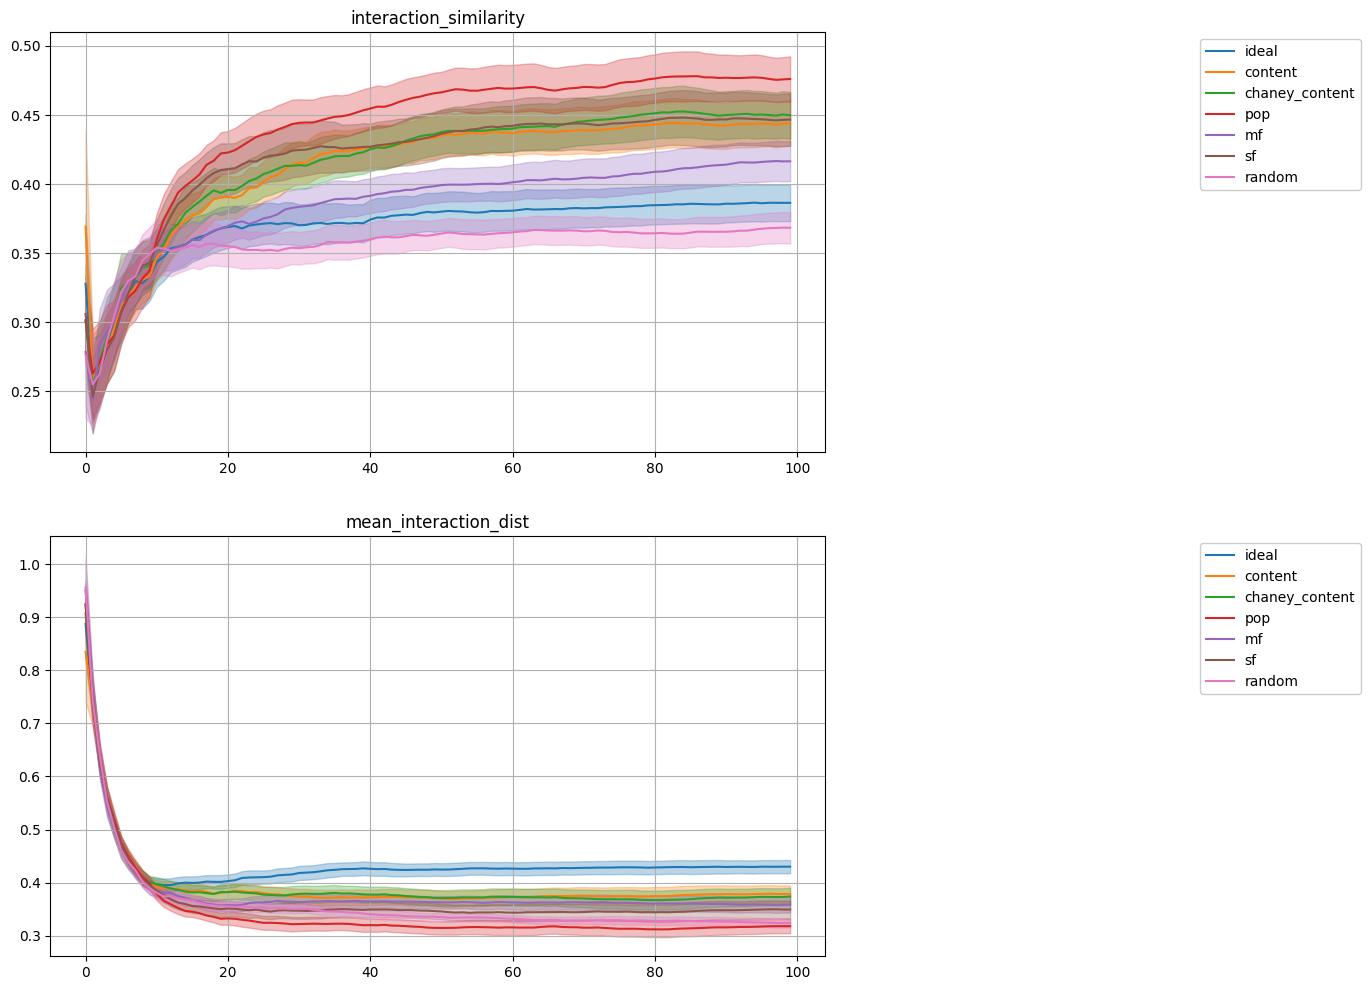

In [1020]:
graph_metrics_and_models(final_results, ["interaction_similarity", "mean_interaction_dist"], model_keys, mult_sd=.3, relative_to_ideal=False)

In [1000]:
result_metrics_normal = {k: defaultdict(list) for k in metric_list}
models = {}

In [1001]:
for i in range(num_sims):
    print("Starting simulation", i+1)
    true_prefs = users[i] # underlying true preferences
    true_scores = true_utils[i]
    noisy_scores = known_utils[i]
    item_representation = items[i].T
    social_network = social_networks[i]

    pairs = [rng.choice(num_users, 2, replace=False) for _ in range(800)]

    init_params = {
        "true_scores": true_scores,
        "noisy_scores": noisy_scores,
        "item_representation": item_representation,
        "social_network": social_network,
        "traits": np.array([1.0, 0.0, 0.0]),
    }

    print("Running ideal:")
    models["ideal"] = run_ideal_sim(true_prefs, true_scores, pairs, init_params, repeated_training=repeated_training)
    ideal_interaction_history = np.hstack(models["ideal"].get_measurements()["interaction_history"][1:])
    # ideal_interaction_history.shape = (total_iters, num_users, 1)

    print("Running content:")
    models["content"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=ContentFiltering, repeated_training=repeated_training)
    print("Running chaney_content:")
    models["chaney_content"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=ChaneyContent, repeated_training=repeated_training)
    print("Running pop:")
    models["pop"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=PopularityRecommender, repeated_training=repeated_training)
    print("Running mf:")
    models["mf"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=ImplicitMF, repeated_training=repeated_training)
    print("Running sf:")
    models["sf"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=SocialFiltering, user_rep=social_network, repeated_training=repeated_training)
    print("Running random:")
    models["random"] = run_sim(item_representation, pairs, ideal_interaction_history, init_params, model=RandomRecommender, repeated_training=repeated_training)

    print("Getting results...")
    for model_key in model_keys:
        model = models[model_key]
        for metric_key in metric_list:
            if not (model_key == "ideal" and (metric_key == "similar_user_jaccard" or metric_key == "sim_user_dist")):
                measurements = model.get_measurements()[metric_key][1:]
                #print("For simulation", i, "model", model_key, "and metric", metric_key, "the result is", measurements)
                result_metrics_normal[metric_key][model_key].append(measurements)
    print("")

Starting simulation 1
Running ideal:


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 90/90 [00:11<00:00,  7.93it/s]


Running content:


100%|██████████| 90/90 [00:19<00:00,  4.61it/s]


...

Running sf:


100%|██████████| 90/90 [00:15<00:00,  5.99it/s]


Running random:


100%|██████████| 90/90 [00:13<00:00,  6.75it/s]

Getting results...



In [1017]:
final_results = defaultdict(lambda: defaultdict(list))
for metric_name, nested_value in result_metrics_normal.items():
    for model_name, metric_value in nested_value.items():
        final_results[metric_name][model_name] = metric_value

Metric interaction_similarity model ideal values: [0.26825    0.17716667 0.164425   0.16040952 0.16141071 0.16157229
 0.16221138 0.16236611 0.16358976 0.16510549 0.17610824 0.18079568
 0.18525557 0.18500311 0.18793647 0.19065708 0.19338941 0.19582368
 0.1945885  0.19406871 0.19348422 0.19333113 0.19435143 0.19547143
 0.19474856 0.19561091 0.19642731 0.19839046 0.19775704 0.19706103
 0.19759991 0.1983242  0.20036636 0.2011251  0.20077309 0.20005279
 0.19900736 0.19897338 0.19841354 0.19967308 0.20056902 0.19965581
 0.19920684 0.20068727 0.20076781 0.20100757 0.20118086 0.20155083
 0.20116044 0.20196394 0.2015045  0.20152694 0.20125062 0.20087873
 0.20031711 0.20002278 0.19971985 0.19926087 0.19906866 0.19874845
 0.19865455 0.19962526 0.19898864 0.19828972 0.19860387 0.19823431
 0.19773912 0.19868912 0.19904812 0.19923576 0.19946674 0.19972021
 0.20034941 0.20081242 0.20120828 0.20115867 0.20163876 0.20200112
 0.20187259 0.20201429 0.20181925 0.20241701 0.20292419 0.20273909
 0.20192657 

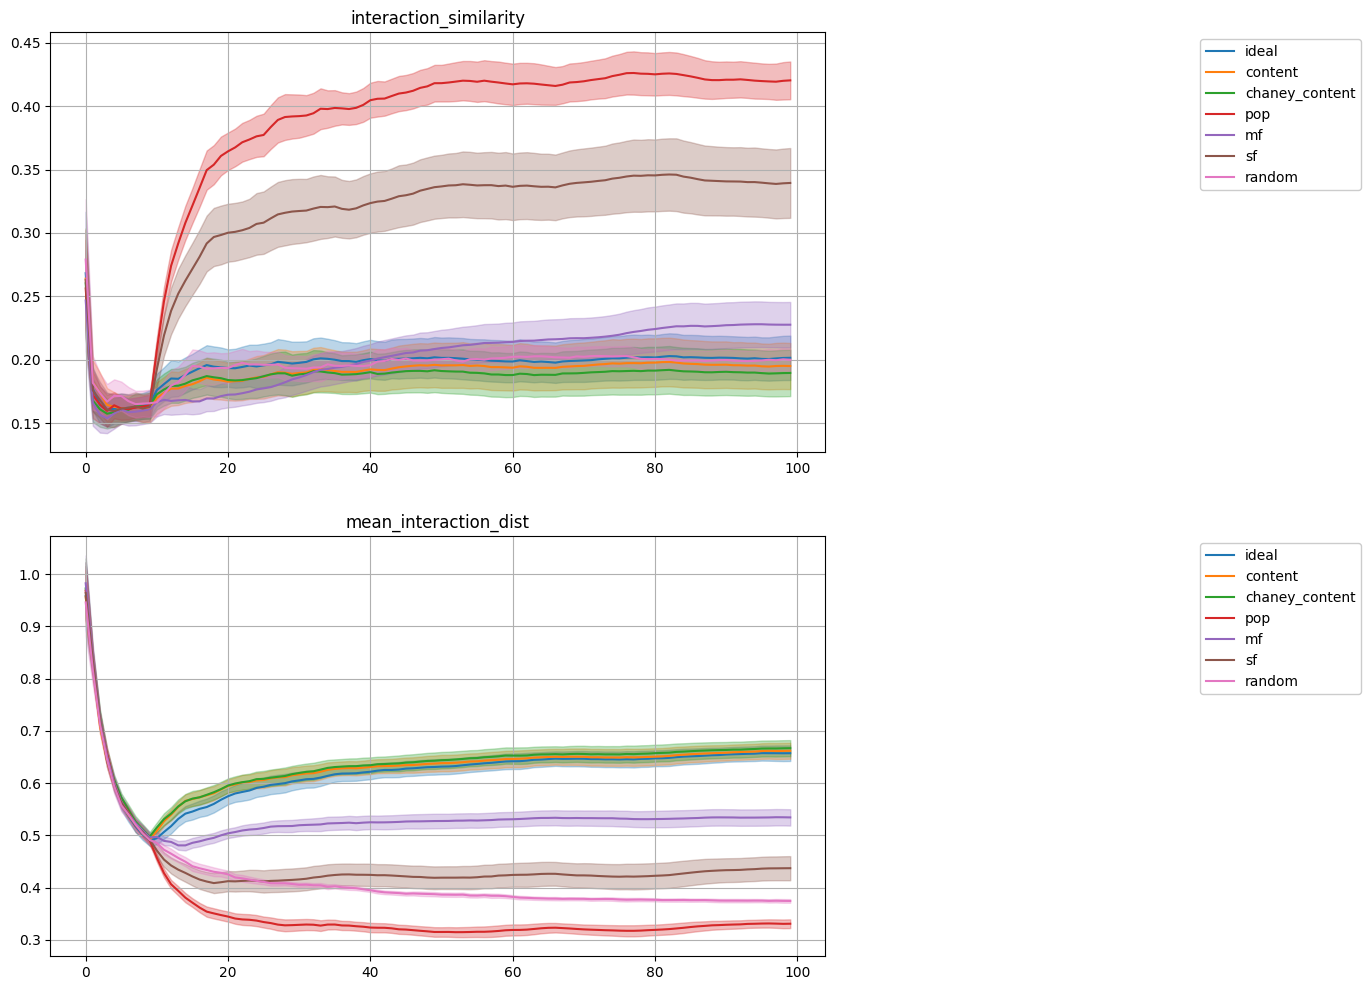

In [1018]:
graph_metrics_and_models(final_results, ["interaction_similarity", "mean_interaction_dist"], model_keys, mult_sd=.3, relative_to_ideal=False)